In [1]:
import pickle
import random
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Decoder, SirenNetUnbatched
from minf.utils import plot_field
from minf.metamol import Metamol
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 32

pdb_file = "../data/6ega_protein.pdb"
sdf_file = "../data/6ega_ligand.sdf"

properties = [
    "wigner_seitz_electron_density",
]

mmol, _ = Metamol.from_complex(pdb_file, sdf_file, size=resolution, properties=properties, b=0.25)

[17:32:27] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


In [3]:
mmol.calculate_field()
vector_field = mmol.to_vector_field()[:, :, :, [0, 1, 9, 11, 12, 18]]

In [4]:
rot=2.9
plot_field(vector_field[:, :, :, 2], cam_rotate=rot, resolution=1024).save("ligand.png")
plot_field(vector_field[:, :, :, 5], cam_rotate=rot, resolution=1024).save("protein.png")

yt : [INFO     ] 2025-02-09 17:32:27,919 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-09 17:32:27,919 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-09 17:32:27,920 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-09 17:32:27,920 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-09 17:32:27,920 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-09 17:32:27,979 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-09 17:32:27,986 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-09 17:32:27,986 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-09 17:32:27,987 Creating volume
yt : [INFO     ] 2025-02-09 17:32:28,003 Creating transfer function
yt : [INFO     ] 2025-02-09 17:32:28,004 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.
yt : [INFO     ] 2025-02-09 17:32:2

In [5]:
net = SirenNetUnbatched(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

decoder = Decoder(
    net,
    # output_shape=[resolution, resolution, resolution, 24, 1],
    output_shape=[resolution, resolution, resolution, 6, 1],
    latent_dim=128,
    n_shapes=1
)

decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=decoder.parameters())

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
min_loss = 9999999
for epoch in (pbar := tqdm(range(20000))):
    loss = decoder(vector_field.cuda(), latent_idx=0)
    optim.zero_grad()
    loss.backward()
    optim.step()
    if loss.item() < min_loss:
        min_loss = loss.item()
        torch.save(decoder.state_dict(), "reconstruction_model.pt")
    if epoch % 100 == 0:
        try: 
            reconstructed = decoder.predict(decoder.latents[0].cuda())
            reconstructed = reconstructed.cpu().detach().squeeze(-1)
            plot_field(reconstructed[:, :, :, 0], cam_rotate=rot, resolution=1024).save(f"ligand_{epoch:07d}.png")
            plot_field(reconstructed[:, :, :, 5], cam_rotate=rot, resolution=1024).save(f"protein_{epoch:07d}.png")
        except Exception:
            ...
    pbar.set_description(f"Epoch {epoch} (loss: {loss.item()})")

yt : [INFO     ] 2025-02-09 17:32:29,722 Parameters: current_time              = 0.0                                                                                                                                                                             | 0/20000 [00:00<?, ?it/s]
yt : [INFO     ] 2025-02-09 17:32:29,722 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-09 17:32:29,723 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-09 17:32:29,723 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-09 17:32:29,723 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-09 17:32:29,766 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-09 17:32:29,772 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-09 17:32:29,772 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-09 17:32:29,774 Creating volume
yt : [INFO     ] 2025-02-09 17:32:29,790 Creat

yt : [INFO     ] 2025-02-09 18:59:43,550 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-09 18:59:43,551 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-09 18:59:43,551 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-09 18:59:43,551 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-09 18:59:43,552 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-09 18:59:43,593 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-09 18:59:43,599 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-09 18:59:43,600 Creating volume
yt : [INFO     ] 2025-02-09 18:59:43,616 Creating transfer function
yt : [INFO     ] 2025-02-09 18:59:43,617 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


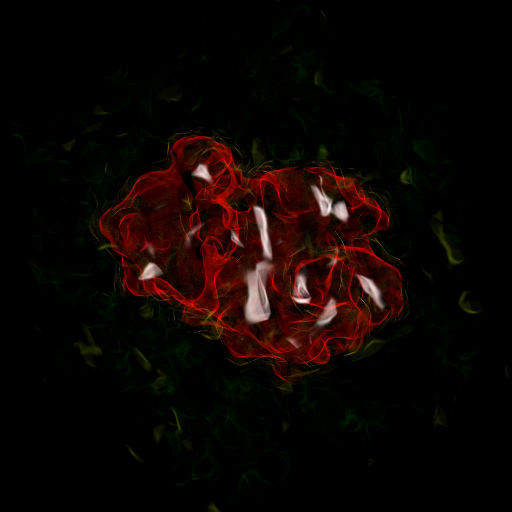

In [9]:
reconstructed = decoder.predict(decoder.latents[0].cuda())
reconstructed = reconstructed.cpu().detach().squeeze(-1)
plot_field(reconstructed[:, :, :, 5], cam_rotate=rot).show()